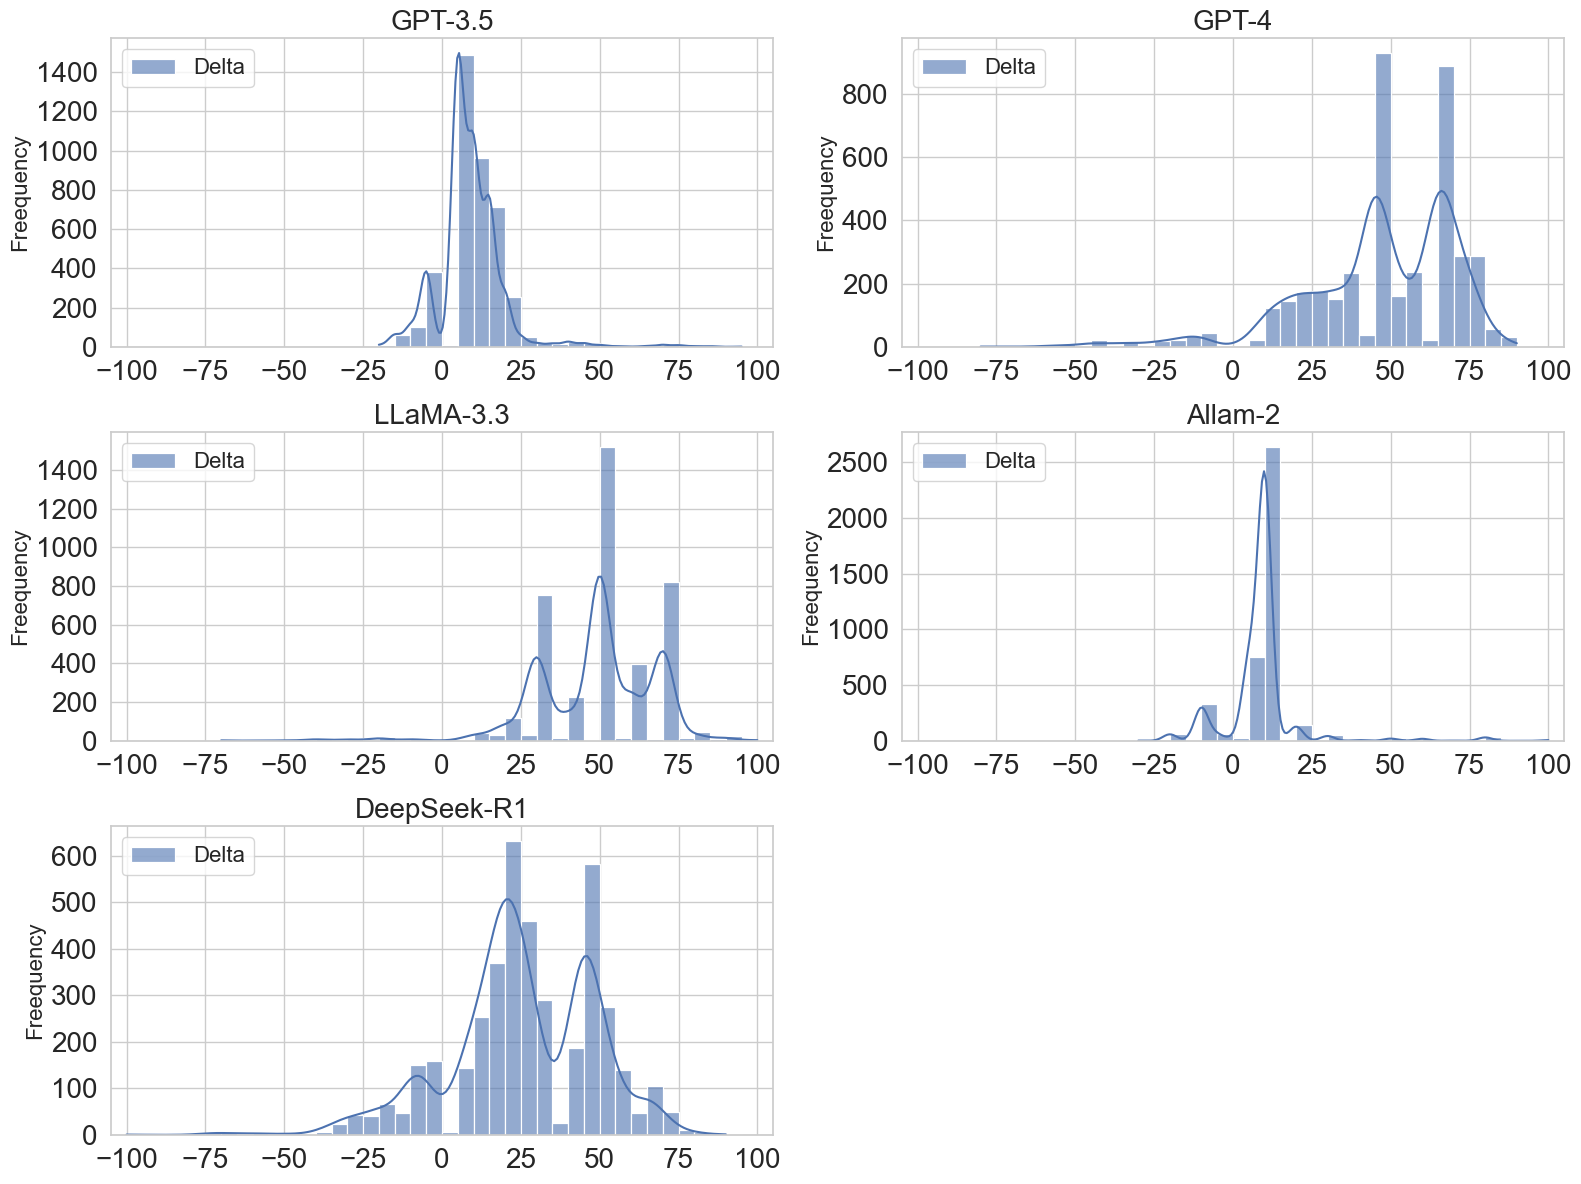

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# ---------- Config ----------
file_paths = {
    "GPT-3.5": "gpt-3.5-turbo.csv",
    "GPT-4": "gpt-4-turbo.csv",
    "LLaMA-3.3": "llama-3.3-70b-versatile.csv",
    "Allam-2": "allam-2-7b.csv",
    "DeepSeek-R1": "deepseek-r1-distill-llama-70b.csv"
}

TITLE_FONTSIZE = 20
TICK_FONTSIZE = 20
LEGEND_FONTSIZE = 16

# ---------- 1) Find global min/max delta for consistent x-axis ----------
min_delta, max_delta = float("inf"), float("-inf")

for fp in file_paths.values():
    df = pd.read_csv(fp)
    dmin = df["delta"].min()
    dmax = df["delta"].max()
    min_delta = min(min_delta, dmin)
    max_delta = max(max_delta, dmax)

# Add a little padding so plots don't touch boundaries
pad = 5
x_min = min_delta - pad
x_max = max_delta + pad

# ---------- 2) Define consistent bins (width=5 like your code) ----------
bin_width = 5
bins = np.arange(np.floor(x_min / bin_width) * bin_width,
                 np.ceil(x_max / bin_width) * bin_width + bin_width,
                 bin_width)

# ---------- 3) Create subplot grid like your reference ----------
plt.figure(figsize=(16, 12))

for i, (model_name, fp) in enumerate(file_paths.items(), 1):
    plt.subplot(3, 2, i)

    df = pd.read_csv(fp)

    # Delta histogram
    sns.histplot(
        df["delta"],
        kde=True,
        bins=bins,
        alpha=0.6,
        label="Delta"
    )

    # Match reference style: remove axis labels, keep ticks
    plt.xlabel(None)
    plt.ylabel("Freequency", fontsize=16)

    # Title per panel
    plt.title(f"{model_name}", fontsize=TITLE_FONTSIZE)

    # Bigger ticks
    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)

    # Same x-axis everywhere
    plt.xlim(x_min, x_max)

    # Legend placement consistent with your reference
    plt.legend(title=None, loc="upper left", fontsize=LEGEND_FONTSIZE)

# Prevent overlapping
plt.tight_layout()
plt.show()


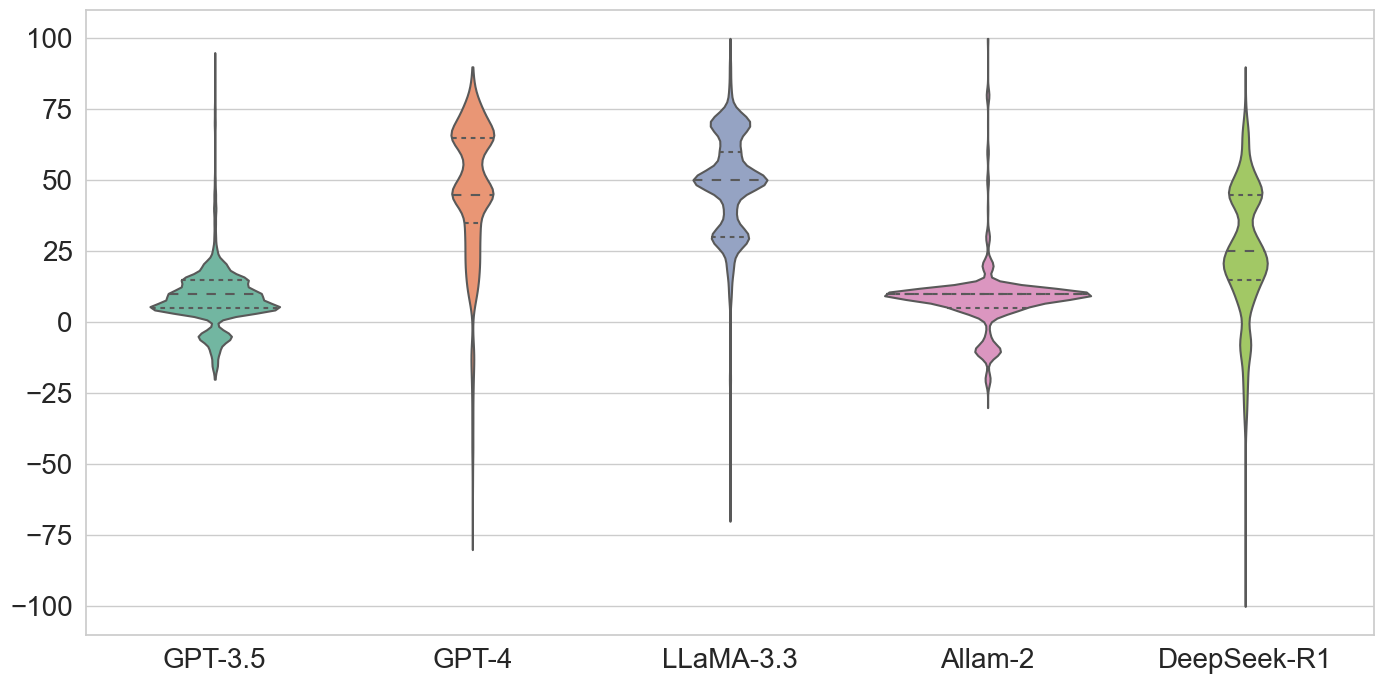

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ---------- Config ----------
file_paths = {
    "GPT-3.5": "gpt-3.5-turbo.csv",
    "GPT-4": "gpt-4-turbo.csv",
    "LLaMA-3.3": "llama-3.3-70b-versatile.csv",
    "Allam-2": "allam-2-7b.csv",
    "DeepSeek-R1": "deepseek-r1-distill-llama-70b.csv"
}

TITLE_FONTSIZE = 20
TICK_FONTSIZE = 20

# ---------- Load and combine data ----------
all_data = []

for model_name, path in file_paths.items():
    df = pd.read_csv(path)
    all_data.append(
        pd.DataFrame({
            "Model": model_name,
            "Delta": df["delta"]
        })
    )

combined_df = pd.concat(all_data, ignore_index=True)

# ---------- Plot ----------
plt.figure(figsize=(14, 7))

ax = sns.violinplot(
    data=combined_df,
    x="Model",
    y="Delta",
    inner="quartile",
    palette="Set2",
    cut=0
)

# ---------- Formatting (match reference style) ----------
ax.set_xlabel("")          # remove axis label
ax.set_ylabel("")          # remove axis label

ax.tick_params(axis="x", labelsize=TICK_FONTSIZE, rotation=0)
ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

plt.tight_layout()
plt.show()


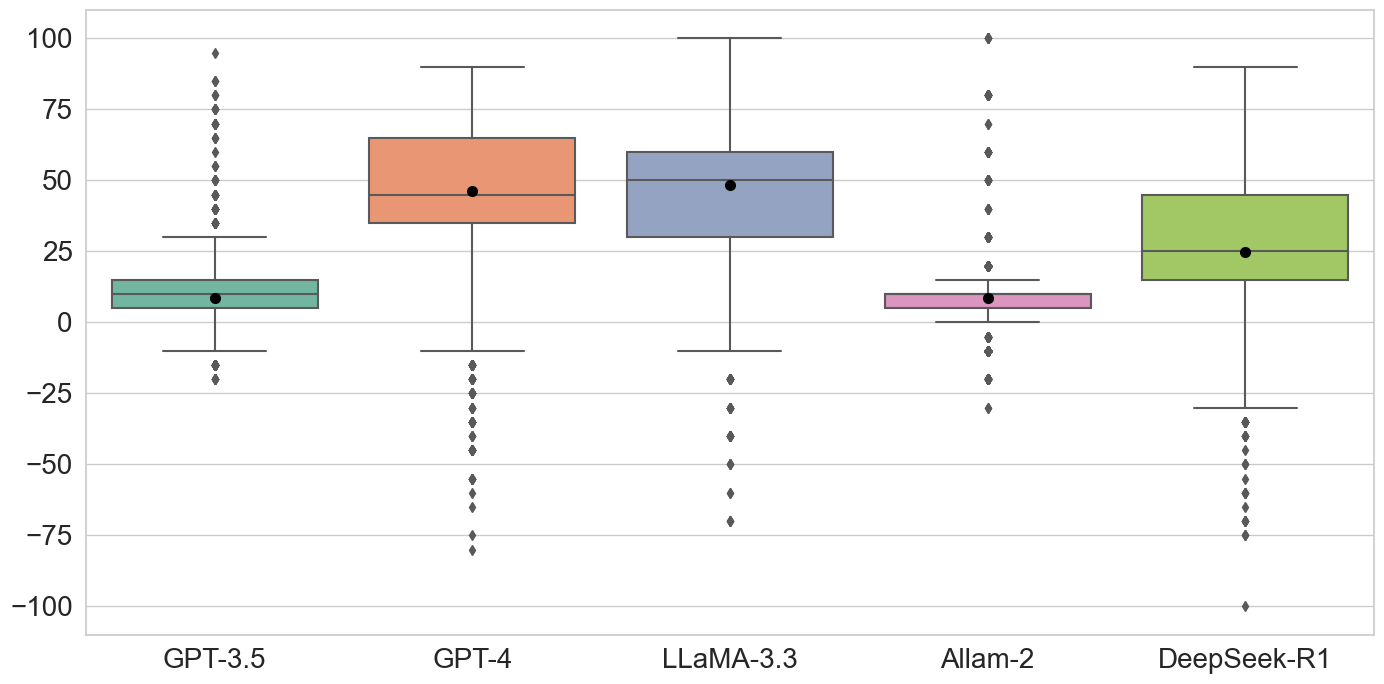

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ---------- Config ----------
file_paths = {
    "GPT-3.5": "gpt-3.5-turbo.csv",
    "GPT-4": "gpt-4-turbo.csv",
    "LLaMA-3.3": "llama-3.3-70b-versatile.csv",
    "Allam-2": "allam-2-7b.csv",
    "DeepSeek-R1": "deepseek-r1-distill-llama-70b.csv"
}

TITLE_FONTSIZE = 20
TICK_FONTSIZE = 20

# ---------- Load + combine data ----------
all_data = []
for model_name, path in file_paths.items():
    df = pd.read_csv(path)
    all_data.append(
        pd.DataFrame({
            "Model": model_name,
            "Delta": df["delta"]
        })
    )

combined_df = pd.concat(all_data, ignore_index=True)

# ---------- Plot ----------
plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=combined_df,
    x="Model",
    y="Delta",
    palette="Set2",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

# ---------- Formatting (match your reference style) ----------

# Remove axis labels but keep ticks
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=TICK_FONTSIZE, rotation=0)
ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

plt.tight_layout()
plt.show()


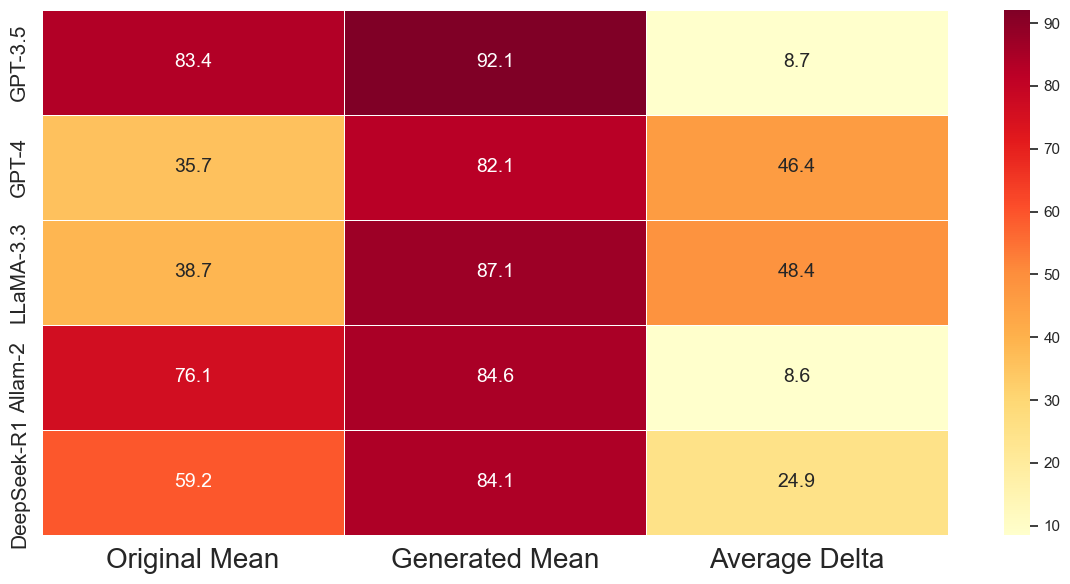

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ---------- Config ----------
file_paths = {
    "GPT-3.5": "gpt-3.5-turbo.csv",
    "GPT-4": "gpt-4-turbo.csv",
    "LLaMA-3.3": "llama-3.3-70b-versatile.csv",
    "Allam-2": "allam-2-7b.csv",
    "DeepSeek-R1": "deepseek-r1-distill-llama-70b.csv"
}

TITLE_FONTSIZE = 20
TICK_FONTSIZE = 16
ANNOT_FONTSIZE = 14

# ---------- Collect summary statistics ----------
summary_data = []

for model_name, path in file_paths.items():
    df = pd.read_csv(path)
    summary_data.append({
        "Model": model_name,
        "Original Mean": df["original_reason_score"].mean(),
        "Generated Mean": df["generated_reason_score"].mean(),
        "Average Delta": df["delta"].mean()
    })

# ---------- Create DataFrame ----------
score_df = pd.DataFrame(summary_data).set_index("Model")

# ---------- Plot ----------
plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    score_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    annot_kws={"fontsize": ANNOT_FONTSIZE}
)

# ---------- Formatting ----------

# Remove axis labels but keep ticks
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=20, rotation=0)
ax.tick_params(axis="y", labelsize=15)

plt.tight_layout()
plt.show()
